In [1]:
import sys
sys.path.append('../src')
import torch
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

encoder = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=True, in_chans=1, num_classes=0)
encoder = encoder.to(device)

test_input = torch.randn(1, 1, 120, 120).to(device)
with torch.no_grad():
    features = encoder(test_input)
print(features.shape)

cuda


torch.Size([1, 640])


In [2]:
import torch.nn as nn

class LensClassifier(nn.Module):
    def __init__(self, encoder, feature_dim=640, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)


model = LensClassifier(encoder).to(device)

test_output = model(test_input)
print(test_output.shape)

torch.Size([1, 2])


In [3]:
import numpy as np
import pandas as pd
import h5py
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

with h5py.File('../data/processed/injected_v1/injected_dataset.h5', 'r') as f:
    images = f['images'][:]

metadata = pd.read_parquet('../data/processed/injected_v1/injected_dataset_metadata.parquet')
labels = metadata['label'].values

indices = np.arange(len(images))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=42)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")


class LensDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx]).float().unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


train_dataset = LensDataset(images[train_idx], labels[train_idx])
val_dataset = LensDataset(images[val_idx], labels[val_idx])
test_dataset = LensDataset(images[test_idx], labels[test_idx])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train: 2791, Val: 598, Test: 599


In [4]:
norm_layer_types = set()
for module in model.modules():
    norm_layer_types.add(type(module).__name__)

norm_related = [name for name in norm_layer_types if 'Norm' in name]
print(norm_related)

['LayerNorm2d', 'NormMlpClassifierHead']


In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

def train_one_epoch(model, loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images_batch, labels_batch in loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item() * images_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_batch).sum().item()
        total += labels_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images_batch, labels_batch in loader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)

            total_loss += loss.item() * images_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels_batch).sum().item()
            total += labels_batch.size(0)

    return total_loss / total, correct / total

In [6]:
n_epochs = 15

history_zoobot = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_zoobot['train_loss'].append(train_loss)
    history_zoobot['train_acc'].append(train_acc)
    history_zoobot['val_loss'].append(val_loss)
    history_zoobot['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.4752, train_acc: 0.7438, val_loss: 0.2293, val_acc: 0.9231
Epoch 2/15 - train_loss: 0.1886, train_acc: 0.9323, val_loss: 0.1231, val_acc: 0.9582
Epoch 3/15 - train_loss: 0.1832, train_acc: 0.9308, val_loss: 0.2766, val_acc: 0.8612
Epoch 4/15 - train_loss: 0.1468, train_acc: 0.9541, val_loss: 0.0884, val_acc: 0.9799
Epoch 5/15 - train_loss: 0.1146, train_acc: 0.9753, val_loss: 0.3308, val_acc: 0.9515
Epoch 6/15 - train_loss: 0.2265, train_acc: 0.9377, val_loss: 0.1665, val_acc: 0.9431
Epoch 7/15 - train_loss: 0.0840, train_acc: 0.9785, val_loss: 0.1255, val_acc: 0.9766
Epoch 8/15 - train_loss: 0.0706, train_acc: 0.9871, val_loss: 0.1203, val_acc: 0.9816
Epoch 9/15 - train_loss: 0.0552, train_acc: 0.9900, val_loss: 0.2073, val_acc: 0.9699
Epoch 10/15 - train_loss: 0.0507, train_acc: 0.9903, val_loss: 0.1544, val_acc: 0.9833
Epoch 11/15 - train_loss: 0.0268, train_acc: 0.9961, val_loss: 0.1528, val_acc: 0.9799
Epoch 12/15 - train_loss: 0.0281, train_acc: 0.9946,

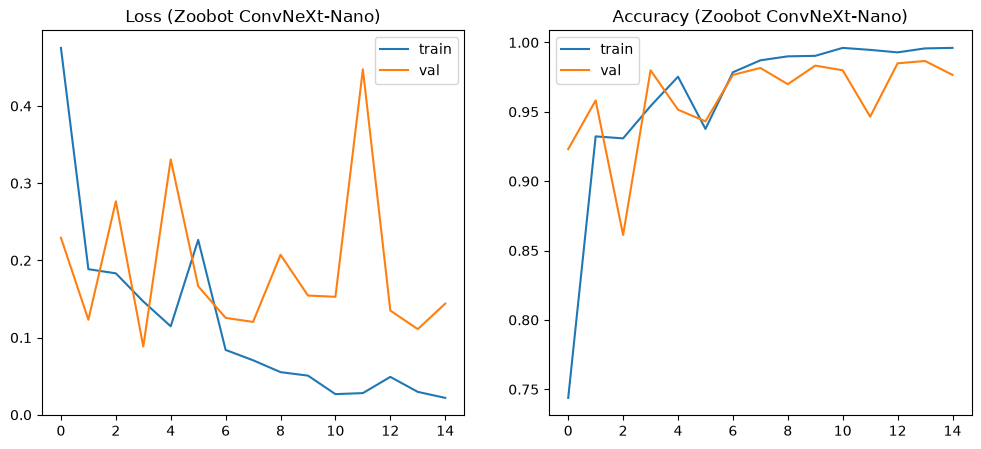

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_zoobot['train_loss'], label='train')
axes[0].plot(history_zoobot['val_loss'], label='val')
axes[0].set_title('Loss (Zoobot ConvNeXt-Nano)')
axes[0].legend()
axes[1].plot(history_zoobot['train_acc'], label='train')
axes[1].plot(history_zoobot['val_acc'], label='val')
axes[1].set_title('Accuracy (Zoobot ConvNeXt-Nano)')
axes[1].legend()
plt.show()

In [8]:
model = LensClassifier(timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=True, in_chans=1, num_classes=0)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

best_val_loss = float('inf')
history_zoobot_v2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_zoobot_v2['train_loss'].append(train_loss)
    history_zoobot_v2['train_acc'].append(train_acc)
    history_zoobot_v2['val_loss'].append(val_loss)
    history_zoobot_v2['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/zoobot_convnext_nano_best.pt')
        print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} [NEW BEST, saved]")
    else:
        print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.3900, train_acc: 0.8241, val_loss: 0.1868, val_acc: 0.9431 [NEW BEST, saved]
Epoch 2/15 - train_loss: 0.1613, train_acc: 0.9416, val_loss: 0.1325, val_acc: 0.9582 [NEW BEST, saved]
Epoch 3/15 - train_loss: 0.1666, train_acc: 0.9409, val_loss: 0.1330, val_acc: 0.9666
Epoch 4/15 - train_loss: 0.1570, train_acc: 0.9459, val_loss: 0.1159, val_acc: 0.9699 [NEW BEST, saved]
Epoch 5/15 - train_loss: 0.0872, train_acc: 0.9764, val_loss: 0.1530, val_acc: 0.9716
Epoch 6/15 - train_loss: 0.0560, train_acc: 0.9867, val_loss: 0.1073, val_acc: 0.9816 [NEW BEST, saved]
Epoch 7/15 - train_loss: 0.0638, train_acc: 0.9896, val_loss: 0.1104, val_acc: 0.9816
Epoch 8/15 - train_loss: 0.0413, train_acc: 0.9896, val_loss: 0.1231, val_acc: 0.9816
Epoch 9/15 - train_loss: 0.0393, train_acc: 0.9921, val_loss: 0.1327, val_acc: 0.9816
Epoch 10/15 - train_loss: 0.0384, train_acc: 0.9936, val_loss: 0.1315, val_acc: 0.9816
Epoch 11/15 - train_loss: 0.0609, train_acc: 0.9896, val_loss: 0.13

In [10]:
eval_model = LensClassifier(timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=False, in_chans=1, num_classes=0)).to(device)
eval_model.load_state_dict(torch.load('../models/zoobot_convnext_nano_best.pt'))
eval_model.eval()

from sklearn.metrics import classification_report, confusion_matrix

all_preds_zoobot = []
all_labels_zoobot = []
all_probs_zoobot = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs = eval_model(images_batch)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_preds_zoobot.extend(predicted.cpu().numpy())
        all_labels_zoobot.extend(labels_batch.numpy())
        all_probs_zoobot.extend(probs.cpu().numpy())

all_preds_zoobot = np.array(all_preds_zoobot)
all_labels_zoobot = np.array(all_labels_zoobot)

print(classification_report(all_labels_zoobot, all_preds_zoobot, target_names=['non-lens', 'lens']))
print("Confusion matrix:")
print(confusion_matrix(all_labels_zoobot, all_preds_zoobot))

              precision    recall  f1-score   support

    non-lens       0.96      1.00      0.98       300
        lens       1.00      0.96      0.98       299

    accuracy                           0.98       599
   macro avg       0.98      0.98      0.98       599
weighted avg       0.98      0.98      0.98       599

Confusion matrix:
[[299   1]
 [ 11 288]]


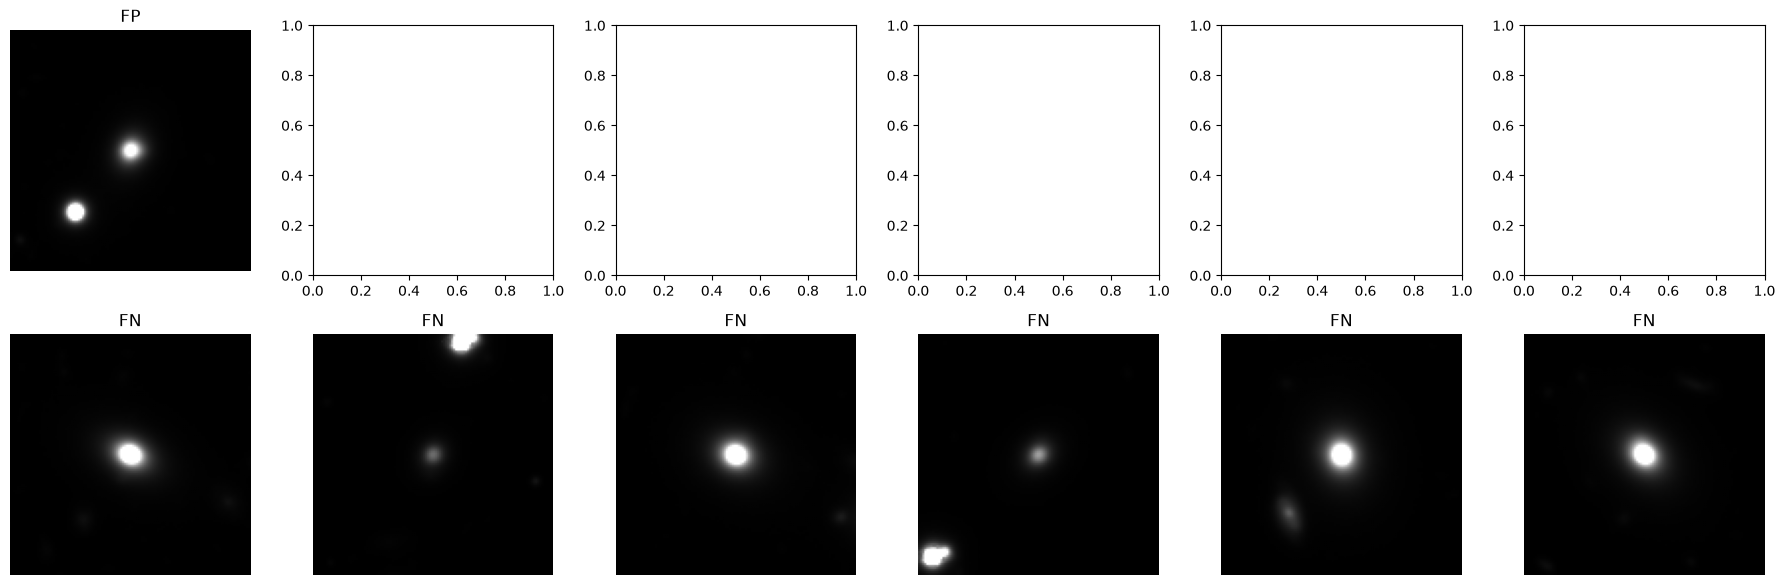

In [11]:
false_positives_idx_z = np.where((all_preds_zoobot == 1) & (all_labels_zoobot == 0))[0]
false_negatives_idx_z = np.where((all_preds_zoobot == 0) & (all_labels_zoobot == 1))[0]

test_images_arr = images[test_idx]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(min(1, len(false_positives_idx_z))):
    ax = axes[0, i]
    idx = false_positives_idx_z[i]
    ax.imshow(test_images_arr[idx], cmap='gray', origin='lower')
    ax.set_title(f"FP")
    ax.axis('off')
for i in range(min(6, len(false_negatives_idx_z))):
    ax = axes[1, i]
    idx = false_negatives_idx_z[i]
    ax.imshow(test_images_arr[idx], cmap='gray', origin='lower')
    ax.set_title(f"FN")
    ax.axis('off')
plt.tight_layout()
plt.show()